# Evaluation
Tính toán các chỉ số (BLEU, METEOR, ROUGE, CIDEr, SPICE) và trực quan hóa 5 mẫu thử.

In [1]:
import json
import random
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
import sys

ROOT = Path(".").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.metrics import compute_metrics
from src.config import IMAGES_DIR, METRICS_PATH, PREDICTIONS_PATH, TEST_DF_PATH

## 1. Tính toán Metrics

In [2]:
print(f"Bắt đầu chấm điểm dựa trên file: {PREDICTIONS_PATH.name}\n")
metrics = compute_metrics(PREDICTIONS_PATH, TEST_DF_PATH)

METRICS_PATH.parent.mkdir(parents=True, exist_ok=True)
with METRICS_PATH.open("w", encoding="utf-8") as output_file:
    json.dump(metrics, output_file, ensure_ascii=False, indent=2)
print(f"Saved metrics to {METRICS_PATH}")

print("\n" + "="*30)
print("🏆 FINAL METRICS SCORES 🏆")
print("="*30)
for metric, score in metrics.items():
    print(f"{metric:>10}: {(score*100):.2f}")
print("="*30)

Bắt đầu chấm điểm dựa trên file: predictions.json

Loading data...
Evaluated on 5000 images.
Tokenizing (PTBTokenizer)...


PTBTokenizer tokenized 307085 tokens at 1701335.55 tokens per second.
PTBTokenizer tokenized 55799 tokens at 646195.97 tokens per second.


Computing metrics...
 - Computing ['BLEU_1', 'BLEU_2', 'BLEU_3', 'BLEU_4']...
{'testlen': 50800, 'reflen': 49731, 'guess': [50800, 45800, 40800, 35800], 'correct': [37999, 21148, 11077, 5813]}
ratio: 1.0214956465785723
 - Computing METEOR...
 - Computing ROUGE_L...
 - Computing CIDEr...
 - Computing SPICE...


Parsing reference captions
Parsing test captions


SPICE evaluation took: 3.484 s
Saved metrics to /home/tam/workspace/ML/rag_captioning/artifacts/baseline/metrics.json

🏆 FINAL METRICS SCORES 🏆
    BLEU_1: 74.80
    BLEU_2: 58.77
    BLEU_3: 45.43
    BLEU_4: 35.13
    METEOR: 28.75
   ROUGE_L: 57.02
     CIDEr: 117.67
     SPICE: 21.90


## 2. Visualize Predictions vs Ground Truths

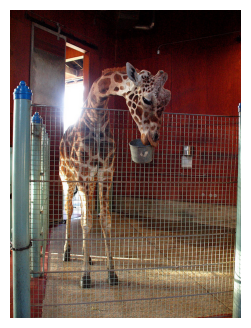

Image ID: 12538
Prediction:
   -  a giraffe standing next to a metal fence
Ground Truths:
   1. A baby giraffe standing next to a wire fence.
   2. a small giraffe inside of a structure behind a fence
   3. A giraffe sticking its head over a wire fence.
   4. a girrafe reaches its neck over a fence to eat from a bucket
   5. A giraffe in a zoo enclosure eating from a small bucket.
--------------------------------------------------------------------------------



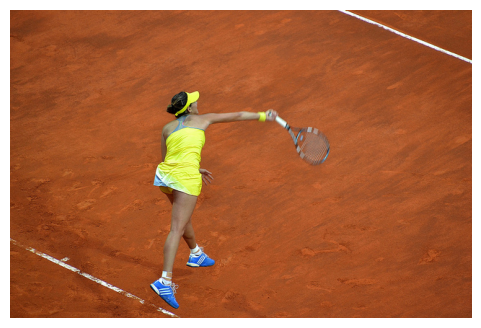

Image ID: 21294
Prediction:
   -  a female tennis player in action on the court
Ground Truths:
   1. A woman in yellow is hitting a tennis ball on a clay court. 
   2. A woman on a clay tennis court returning a hit
   3. A tennis player prepares to return the ball
   4. A woman playing tennis in a yellow dress.
   5. A beautiful young lady swinging a tennis racquet.
--------------------------------------------------------------------------------



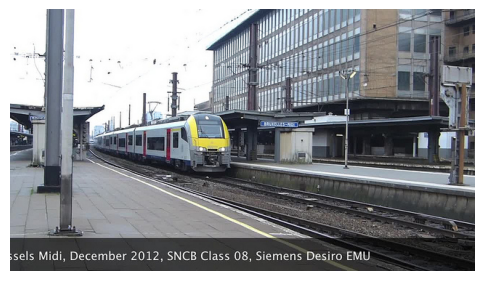

Image ID: 21769
Prediction:
   -  a train that is on the tracks next to a building
Ground Truths:
   1. A train coming down the tracks in a city. 
   2. A subway train that is yellow and white going down the rails. 
   3. this is a silver train riding the rails
   4. a train that is next to a big building
   5. A train on the tracks going by a building.
--------------------------------------------------------------------------------



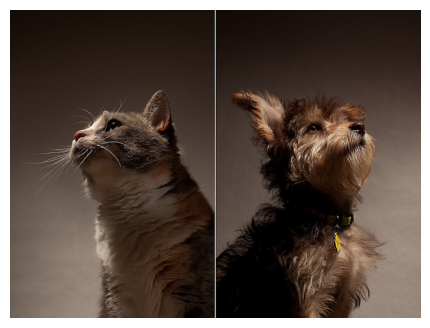

Image ID: 8592
Prediction:
   -  a cat and a dog stare at each other
Ground Truths:
   1. A dog and a cat standing side by side.
   2. Two side by side pictures show a dog and a cat.
   3. a small cat and small dog looking in the opposite direction.
   4. a close up of a cat and a dog both looking upward
   5. Split picture with a multi-color cat on the left and a brownish colored dog on the right
--------------------------------------------------------------------------------



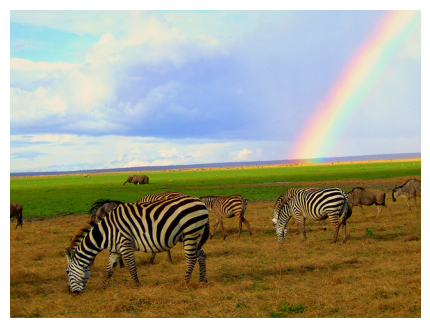

Image ID: 5599
Prediction:
   -  a group of zebras grazing in a field with a rainbow in the background
Ground Truths:
   1. A herd of zebras grazing with a rainbow behind.
   2. A herd of zebras grazing in a field and a rainbow.
   3. The zebras are outside under the rainbow in the sky.
   4. A group of zebras and other animals grazing in a field with a rainbow in the background.
   5. Clouds with a rainbow in the sky of an open field with zebras grazing on the grass.
--------------------------------------------------------------------------------



In [3]:
# Tải lại dự đoán dưới dạng dictionary {imgid: caption}
with open(PREDICTIONS_PATH, "r", encoding="utf-8") as f:
    preds = {int(p["imgid"]): p["caption"] for p in json.load(f)}

# Tải test dataset
test_df = pd.read_parquet(TEST_DF_PATH)

# Lấy ngẫu nhiên 5 ảnh (đổi random_state để xem các ảnh khác)
sample_df = test_df.sample(5, random_state=42)

for _, row in sample_df.iterrows():
    imgid = int(row["imgid"])
    image_path = IMAGES_DIR / row["filepath"] / row["filename"]
    
    predicted_caption = preds.get(imgid, "NO PREDICTION FOUND")
    ground_truths = row["all_raws"]
    
    # Hiển thị ảnh
    plt.figure(figsize=(6, 4))
    try:
        img = Image.open(image_path).convert("RGB")
        plt.imshow(img)
        plt.axis("off")
        plt.show()
    except Exception as e:
        print(f"⚠️ Error loading image {image_path}: {e}")
        continue
    
    # In caption
    print(f"Image ID: {imgid}")
    print(f"Prediction:")
    print(f"   -  {predicted_caption}")
    print(f"Ground Truths:")
    for i, gt in enumerate(ground_truths, 1):
        print(f"   {i}. {gt}")
    print("-" * 80 + "\n")